## Detecting Monthly Anomalies in Sea Surface Salinity Data

This notebook serves to show how Data from the ESA CCI Toolbox can be accessed and how operations can be performed on the data to retrieve an output dataset.
For this, we focus on a Sea Surface Salinity Dataset. We bring it to a monthly resolution, create a climatology from it and use this climatology to find anomalies.

In [1]:
import math
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import pandas as pd

from esa_climate_toolbox.core import list_ecvs
from esa_climate_toolbox.core import list_ecv_datasets
from esa_climate_toolbox.core import open_data

from xcube.core.store import new_data_store

%matplotlib inline

We first create an overview about the data that is available from the ESA CCI Toolbox:

In [2]:
list_ecvs()

['SEASTATE',
 'LST',
 'SOILMOISTURE',
 'SEAICE',
 'WATERVAPOUR',
 'FIRE',
 'PREC',
 'OC',
 'VEGETATION',
 'RD',
 'BIOMASS',
 'AEROSOL',
 'SNOW',
 'OZONE',
 'SEALEVEL',
 'GHG',
 'ICESHEETS',
 'SST',
 'LC',
 'PERMAFROST',
 'CLOUD',
 'LAKES',
 'SEASURFACESALINITY']

In [3]:
list_ecv_datasets("SEASURFACESALINITY")

[('esacci.SEASURFACESALINITY.15-days.L4.SSS.multi-sensor.multi-platform.GLOBAL-MERGED_OI_Monthly_CENTRED_15Day_0-25deg.4-41.r1',
  'esa-cci'),
 ('esacci.SEASURFACESALINITY.15-days.L4.SSS.multi-sensor.multi-platform.GLOBAL-MERGED_OI_Monthly_CENTRED_15Day_0-25deg.5-5.r1',
  'esa-cci'),
 ('esacci.SEASURFACESALINITY.15-days.L4.SSS.multi-sensor.multi-platform.MERGED_OI_Monthly_CENTRED_15Day_25km.2-31.r1',
  'esa-cci'),
 ('esacci.SEASURFACESALINITY.15-days.L4.SSS.multi-sensor.multi-platform.MERGED_OI_Monthly_CENTRED_15Day_25km.3-21.r1',
  'esa-cci'),
 ('esacci.SEASURFACESALINITY.15-days.L4.SSS.multi-sensor.multi-platform.POLAR-MERGED_OI_Monthly_CENTRED_15Day_25kmEASE2-NH.05-5.r1',
  'esa-cci'),
 ('esacci.SEASURFACESALINITY.15-days.L4.SSS.multi-sensor.multi-platform.POLAR-MERGED_OI_Monthly_CENTRED_15Day_25kmEASE2-NH.4-41.r1',
  'esa-cci'),
 ('esacci.SEASURFACESALINITY.15-days.L4.SSS.multi-sensor.multi-platform.POLAR-MERGED_OI_Monthly_CENTRED_15Day_25kmEASE2-SH.05-5.r1',
  'esa-cci'),
 ('esacc

There is a lot of data available from the kerchunk store (`esa-cci-kc`), which is a good choice. We pick one of these.

In [4]:
sss_ds = open_data("ESACCI-SEASURFACESALINITY-L4-SSS-GLOBAL-MERGED_OI_Monthly_CENTRED_15Day_0.25deg-20100115-20231215-fv5.5-kr1.0")[0]
sss_ds

<xarray.Dataset> Size: 7GB
Dimensions:           (time: 335, lat: 720, lon: 1440)
Coordinates:
  * time              (time) datetime64[ns] 3kB 2010-01-15 ... 2023-12-15
  * lat               (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon               (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    isc_qc            (time, lat, lon) int8 347MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    lsc_qc            (time, lat, lon) int8 347MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    noutliers         (time, lat, lon) int16 695MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    pct_var           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss               (time, lat, lon) float32 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_qc            (time, lat, lon) int8 347MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_random_error  (time, lat, lon) float32 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    total_nobs        (time, lat, lon) int16 695MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/42)
    Conventions:               CF-1.8
    cdm_data_type:             Grid
    comment:                   There is a seasonal varying bias (<0.05 pss pe...
    creation_time:             ['23-Sep-2024 10:23:13', '23-Sep-2024 10:23:32...
    creator_email:             jean-luc.vergely@acri-st.fr
    creator_name:              ACRI-ST,LOCEAN
    ...                        ...
    time_coverage_duration:    P13Y
    time_coverage_end:         20231230T235959Z
    time_coverage_resolution:  P15D
    time_coverage_start:       20100101T000000Z
    title:                     ESA CCI Sea Surface Salinity ECV produced at a...
    tracking_id:               See individual files for more details

The dataset's time ranges from 2010 to 2023, it appears to be a good choice for our task at hand. However, the temporal resolution is not fit for our climatology, so we bring the data to a monthly resolution using the `temporal_aggregation` operation.

In [5]:
from esa_climate_toolbox.ops import temporal_aggregation

In [6]:
sss_ds_mon = temporal_aggregation(sss_ds, method="mean", period="MS")
sss_ds_mon

<xarray.Dataset> Size: 9GB
Dimensions:           (time: 168, lat: 720, lon: 1440)
Coordinates:
  * time              (time) datetime64[ns] 1kB 2010-01-01 ... 2023-12-01
  * lat               (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon               (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    isc_qc            (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    lsc_qc            (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    noutliers         (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    pct_var           (time, lat, lon) float32 697MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss               (time, lat, lon) float32 697MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_qc            (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_random_error  (time, lat, lon) float32 697MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    total_nobs        (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/42)
    Conventions:               CF-1.8
    cdm_data_type:             Grid
    comment:                   There is a seasonal varying bias (<0.05 pss pe...
    creation_time:             ['23-Sep-2024 10:23:13', '23-Sep-2024 10:23:32...
    creator_email:             jean-luc.vergely@acri-st.fr
    creator_name:              ACRI-ST,LOCEAN
    ...                        ...
    time_coverage_duration:    P5083D
    time_coverage_end:         2023-12-01T00:00:00
    time_coverage_resolution:  P1M
    time_coverage_start:       2010-01-01T00:00:00
    title:                     ESA CCI Sea Surface Salinity ECV produced at a...
    tracking_id:               See individual files for more details

In [7]:
sss_ds_mon = temporal_aggregation(sss_ds, method="mean", period="MS")
sss_ds_mon

<xarray.Dataset> Size: 9GB
Dimensions:           (time: 168, lat: 720, lon: 1440)
Coordinates:
  * time              (time) datetime64[ns] 1kB 2010-01-01 ... 2023-12-01
  * lat               (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon               (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    isc_qc            (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    lsc_qc            (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    noutliers         (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    pct_var           (time, lat, lon) float32 697MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss               (time, lat, lon) float32 697MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_qc            (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_random_error  (time, lat, lon) float32 697MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    total_nobs        (time, lat, lon) float64 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/42)
    Conventions:               CF-1.8
    cdm_data_type:             Grid
    comment:                   There is a seasonal varying bias (<0.05 pss pe...
    creation_time:             ['23-Sep-2024 10:23:13', '23-Sep-2024 10:23:32...
    creator_email:             jean-luc.vergely@acri-st.fr
    creator_name:              ACRI-ST,LOCEAN
    ...                        ...
    time_coverage_duration:    P5083D
    time_coverage_end:         2023-12-01T00:00:00
    time_coverage_resolution:  P1M
    time_coverage_start:       2010-01-01T00:00:00
    title:                     ESA CCI Sea Surface Salinity ECV produced at a...
    tracking_id:               See individual files for more details

To check, we pick two timesteps that should have been merged to one and see whether the corresponding entry in the new monthly dataset is correct for a small random region.

In [8]:
ts_1 = sss_ds.sss.isel(dict(time=1, lat=slice(350, 355), lon=slice(0, 5)))
pd.Timestamp(ts_1.time.values)

Timestamp('2010-02-01 00:00:00')

In [9]:
ts_1.values

array([[35.035065, 34.84998 , 34.818413, 34.94524 , 35.006683],
       [34.959007, 35.045353, 34.90442 , 34.78569 , 34.83806 ],
       [34.65255 , 35.087425, 34.833267, 34.54235 , 34.684395],
       [34.508   , 34.723526, 34.609356, 34.4068  , 34.452435],
       [34.394497, 34.49144 , 34.583946, 34.28203 , 34.470222]],
      dtype=float32)

In [10]:
ts_2 = sss_ds.sss.isel(dict(time=2, lat=slice(350, 355), lon=slice(0, 5)))
pd.Timestamp(ts_2.time.values)

Timestamp('2010-02-15 00:00:00')

In [11]:
ts_2.values

array([[35.074165, 34.98179 , 34.878918, 34.94488 , 34.93579 ],
       [34.970737, 35.282207, 34.923973, 34.89602 , 34.9062  ],
       [34.686787, 35.088863, 34.935616, 34.651955, 35.001675],
       [34.570087, 34.7526  , 34.77374 , 34.546974, 34.629807],
       [34.47966 , 34.56636 , 34.5409  , 34.324345, 34.6267  ]],
      dtype=float32)

In [12]:
ts_agg = sss_ds_mon.sss.isel(dict(time=1, lat=slice(350, 355), lon=slice(0, 5)))
pd.Timestamp(ts_agg.time.values)

Timestamp('2010-02-01 00:00:00')

In [13]:
ts_agg.values

array([[35.054615, 34.915886, 34.848663, 34.94506 , 34.971237],
       [34.964874, 35.16378 , 34.914196, 34.840855, 34.87213 ],
       [34.66967 , 35.088142, 34.88444 , 34.597153, 34.843033],
       [34.539043, 34.738064, 34.691547, 34.476887, 34.541122],
       [34.43708 , 34.5289  , 34.562424, 34.303185, 34.548462]],
      dtype=float32)

Everything looks fine, so we can create the climatology using the `climatology` operation.

In [14]:
from esa_climate_toolbox.ops import climatology

In [15]:
sss_ds_clim = climatology(sss_ds_mon, var="sss")
sss_ds_clim

/home/conda/toniof/56fad57a-1774370984-267-ke-ec-demo/lib/python3.14/site-packages/esa_climate_toolbox/ops/aggregate.py:138: UserWarning: no explicit representation of timezones available for np.datetime64
  climatology_bounds = xr.DataArray(data=da.tile(np.array([time_min, time_max],


<xarray.Dataset> Size: 50MB
Dimensions:             (time: 12, lat: 720, lon: 1440, nv: 2)
Coordinates:
  * time                (time) datetime64[ns] 96B 2010-01-01 ... 2010-12-01
  * lat                 (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                 (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Dimensions without coordinates: nv
Data variables:
    sss                 (time, lat, lon) float32 50MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    climatology_bounds  (time, nv) datetime64[us] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/42)
    Conventions:               CF-1.8
    cdm_data_type:             Grid
    comment:                   There is a seasonal varying bias (<0.05 pss pe...
    creation_time:             ['23-Sep-2024 10:23:13', '23-Sep-2024 10:23:32...
    creator_email:             jean-luc.vergely@acri-st.fr
    creator_name:              ACRI-ST,LOCEAN
    ...                        ...
    time_coverage_duration:    P5083D
    time_coverage_end:         2023-12-01T00:00:00
    time_coverage_resolution:  P1M
    time_coverage_start:       2010-01-01T00:00:00
    title:                     ESA CCI Sea Surface Salinity ECV produced at a...
    tracking_id:               See individual files for more details

We save this one, so we can use it as input to the `anomaly_external` operation.

In [16]:
output_store = new_data_store(
    "file",
    root="out"
)

In [17]:
output_store.write_data(sss_ds_clim, "sss_climatology.zarr", replace=True)

'sss_climatology.zarr'

In [18]:
from esa_climate_toolbox.ops import anomaly_external

In [19]:
sss_anom_ds = anomaly_external(sss_ds_mon, "out/sss_climatology.zarr")
sss_anom_ds

<xarray.Dataset> Size: 697MB
Dimensions:  (time: 168, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2010-01-01 2010-02-01 ... 2023-12-01
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Data variables:
    sss      (time, lat, lon) float32 697MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                CF-1.8
    cdm_data_type:              Grid
    comment:                    There is a seasonal varying bias (<0.05 pss p...
    creation_time:              ['23-Sep-2024 10:23:13', '23-Sep-2024 10:23:3...
    creator_email:              jean-luc.vergely@acri-st.fr
    creator_name:               ACRI-ST,LOCEAN
    ...                         ...
    title:                      ESA CCI Sea Surface Salinity ECV produced at ...
    tracking_id:                See individual files for more details
    geospatial_lon_resolution:  0.25
    geospatial_lat_resolution:  0.25
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-180.0 -90.0, -180.0 90.0, 180.0 90....

It worked and now we want to plot it. To find meaningful upper and lower limits for the color bar, we can use the `statistics` operation to see what are the min and max values of the anomalies dataset.

In [20]:
from esa_climate_toolbox.ops import statistics

In [21]:
stats = statistics(sss_anom_ds, var="sss", methods=["min", "max"])
stats

<xarray.Dataset> Size: 697MB
Dimensions:  (time: 168, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2010-01-01 2010-02-01 ... 2023-12-01
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Data variables:
    sss      (time, lat, lon) float32 697MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_min  float32 4B dask.array<chunksize=(), meta=np.ndarray>
    sss_max  float32 4B dask.array<chunksize=(), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                CF-1.8
    cdm_data_type:              Grid
    comment:                    There is a seasonal varying bias (<0.05 pss p...
    creation_time:              ['23-Sep-2024 10:23:13', '23-Sep-2024 10:23:3...
    creator_email:              jean-luc.vergely@acri-st.fr
    creator_name:               ACRI-ST,LOCEAN
    ...                         ...
    title:                      ESA CCI Sea Surface Salinity ECV produced at ...
    tracking_id:                See individual files for more details
    geospatial_lon_resolution:  0.25
    geospatial_lat_resolution:  0.25
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-180.0 -90.0, -180.0 90.0, 180.0 90....

In [22]:
stats.sss_min.values

array(-18.103695, dtype=float32)

In [23]:
stats.sss_max.values

array(18.93481, dtype=float32)

Now that we have these, we can have a look at the results. We plot all anomalies for one month over the span of the 14 years covered by the dataset.

In [24]:
# select here to set the month to plot, 0 stands for January, 11 for December
month_to_plot = 6

# select here the threshold for plotting anomaly values linearly, the smaller the value, the more anomalies you will see
linthreshold = 0.7

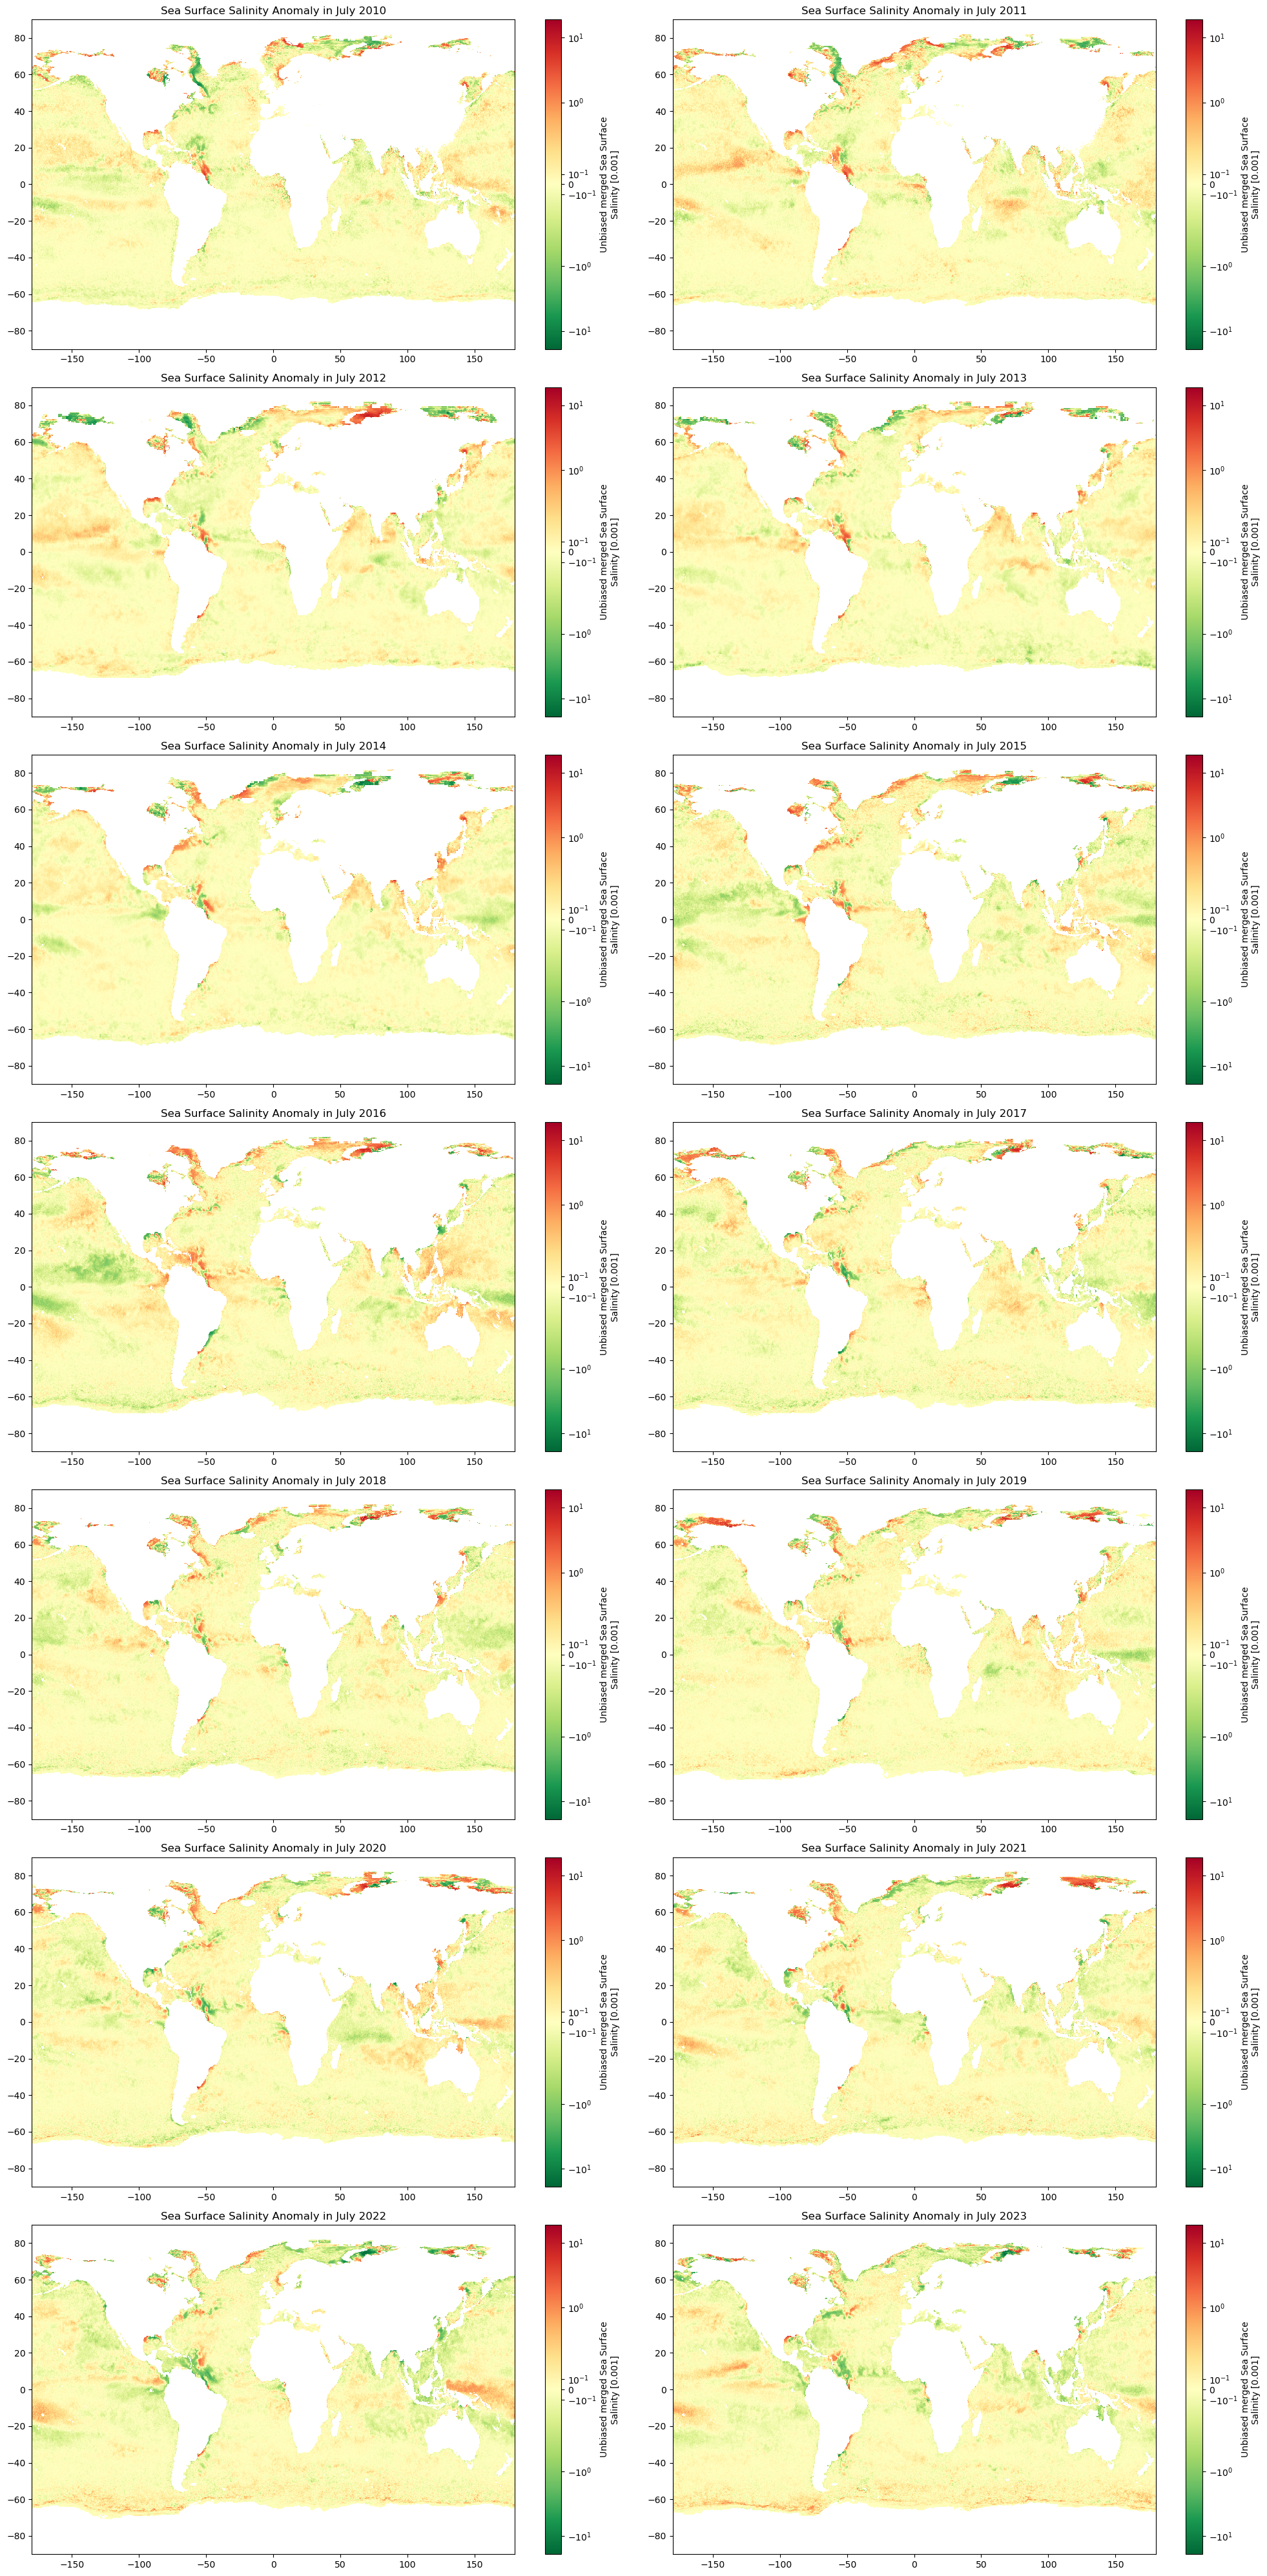

In [25]:
fig, axes = plt.subplots(7, 2, figsize=(20, 40))

ticks = [-19, -10, -1, 0, 1, 10, 19]
plots = []
for i in range(month_to_plot, 168, 12):
    year = pd.Timestamp(sss_anom_ds.time[i].values).strftime("%Y")
    month = pd.Timestamp(sss_anom_ds.time[i].values).strftime("%B")
    ax_index = i / 12
    plots.append(
        (
            sss_anom_ds["sss"].isel(time=i),
            f"Sea Surface Salinity Anomaly in {month} {year}",
            axes[int((ax_index / 2) % 7), int(math.floor(ax_index % 2))],
            dict(norm=colors.SymLogNorm(linthresh=linthreshold, vmin=-19, vmax=19)),
        )
    )

for data, title, ax, kwargs in plots:
    data.plot(
        ax=ax,
        cmap="RdYlGn_r",
        robust=True,
        **kwargs
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

Lastly, we are set to write out the anomaly dataset.

In [26]:
output_store.write_data(sss_anom_ds, "sss_anomalies.zarr", replace=True)

'sss_anomalies.zarr'